# Phase 9 — Module hóa, tái lập kết quả và thí nghiệm E2 (Control + Evolving)

Mục tiêu:
1. Tách logic đã đóng băng ở notebook 02–08 thành package `src/` (không đổi thuật toán).
2. Chứng minh `src/` **tái lập chính xác** 5 kết quả đã đóng băng ở Phase 7/8.
3. Chạy ADWIN **live** (không hard-code 1183/1247 như notebook 08).
4. Bổ sung thí nghiệm còn thiếu **E2 = Control + Evolving Fuzzy**.
5. Stress test: nếu detector báo động nhầm trên Control thì cơ chế thích nghi gây hại bao nhiêu?

Ngưỡng $\tau = 0.67$ giữ nguyên (chọn trên Validation ở Phase 3). Không dùng nhãn Test để tinh chỉnh bất cứ thứ gì.

In [1]:
import sys, platform
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data import load_dataset, make_scenarios, SUDDEN_DRIFT_POINT, GRADUAL_DRIFT_END
from src.fuzzy import FuzzySystem, TAU
from src.drift import detect_all, RIVER_VERSION, FixedDetections
from src.evolving import PrequentialRunner
from src.evaluation import evaluate
print("Python:", platform.python_version(), "| numpy", np.__version__, "| pandas", pd.__version__, "| river", RIVER_VERSION)
df = load_dataset()
scenarios = make_scenarios(df)
for k, s in scenarios.items():
    print(f"{k:14s} n={len(s)}  failures={int(s['Machine failure'].sum())}  UDI {s.UDI.iloc[0]}→{s.UDI.iloc[-1]}")

Python: 3.10.12 | numpy 2.2.6 | pandas 2.3.3 | river 0.22.0
Control        n=2000  failures=39  UDI 8001→10000
Sudden Drift   n=2000  failures=39  UDI 8001→10000
Gradual Drift  n=2000  failures=39  UDI 8001→10000


## 9.1 — Tái lập điểm số Static và ADWIN live

So với giá trị đã ghi ở Phase 5: mean score Control 0.315161, Sudden 0.381982, Gradual 0.382425; ADWIN: Control [], Sudden [1183], Gradual [1247].

In [2]:
static = FuzzySystem()
static_scores = {k: static.score_stream(s) for k, s in scenarios.items()}
expected_mean = {"Control": 0.315161, "Sudden Drift": 0.381982, "Gradual Drift": 0.382425}
expected_det = {"Control": [], "Sudden Drift": [1183], "Gradual Drift": [1247]}
live_det = {}
for k, sc in static_scores.items():
    live_det[k] = detect_all(sc)
    print(f"{k:14s} mean={sc.mean():.6f} (Phase 5: {expected_mean[k]})  ADWIN live={live_det[k]} (Phase 5: {expected_det[k]})")
    assert abs(sc.mean() - expected_mean[k]) < 1e-6
    assert live_det[k] == expected_det[k]
print("\nStatic score reproduction: PASS | Live ADWIN reproduction: PASS")
print("Detection delay — Sudden:", live_det["Sudden Drift"][0] - SUDDEN_DRIFT_POINT,
      "| Gradual (sau khi drift đạt cực đại t=1200):", live_det["Gradual Drift"][0] - GRADUAL_DRIFT_END)

Control        mean=0.315161 (Phase 5: 0.315161)  ADWIN live=[] (Phase 5: [])
Sudden Drift   mean=0.381982 (Phase 5: 0.381982)  ADWIN live=[1183] (Phase 5: [1183])
Gradual Drift  mean=0.382425 (Phase 5: 0.382425)  ADWIN live=[1247] (Phase 5: [1247])

Static score reproduction: PASS | Live ADWIN reproduction: PASS
Detection delay — Sudden: 183 | Gradual (sau khi drift đạt cực đại t=1200): 47


## 9.2 — Chạy toàn bộ ma trận thực nghiệm bằng pipeline prequential của `src/`

Mỗi mẫu: **chấm điểm bằng tri thức hiện tại → dự đoán → cập nhật ADWIN → (nếu đang thu buffer) đưa vào buffer**. Sau đủ $W=200$ mẫu, dịch chuyển MF của RPM/Torque. Static = cùng pipeline nhưng tắt thích nghi.

In [3]:
FROZEN = {  # Phase 8.9 (TP, TN, FP, FN)
    ("Control", "Static"): (13, 1927, 34, 26),
    ("Sudden Drift", "Static"): (18, 1847, 114, 21),
    ("Sudden Drift", "Evolving"): (15, 1905, 56, 24),
    ("Gradual Drift", "Static"): (18, 1848, 113, 21),
    ("Gradual Drift", "Evolving"): (14, 1900, 61, 25),
}
rows, logs, events = [], {}, {}
for scen, stream in scenarios.items():
    for model in ["Static", "Evolving"]:
        runner = PrequentialRunner(evolve=(model == "Evolving"))
        log = runner.run(stream)
        logs[(scen, model)] = log
        events[(scen, model)] = runner.events
        m = evaluate(log.label, log.score, TAU)
        rows.append({"Experiment": None, "Scenario": scen, "Model": model, **m})
summary = pd.DataFrame(rows)
exp_id = {("Control","Static"):"E1", ("Control","Evolving"):"E2", ("Sudden Drift","Static"):"E3",
          ("Sudden Drift","Evolving"):"E4", ("Gradual Drift","Static"):"E5a", ("Gradual Drift","Evolving"):"E5b"}
summary["Experiment"] = [exp_id[(r.Scenario, r.Model)] for r in summary.itertuples()]
for key, cm in FROZEN.items():
    r = summary[(summary.Scenario == key[0]) & (summary.Model == key[1])].iloc[0]
    assert (r.TP, r.TN, r.FP, r.FN) == cm, key
print("Frozen Phase 7/8 confusion matrices reproduced exactly: PASS (5/5)")
pd.set_option("display.width", 200)
summary.round(4)

Frozen Phase 7/8 confusion matrices reproduced exactly: PASS (5/5)


,Experiment,Scenario,Model,TP,TN,FP,FN,Precision,Recall,F1,FPR,FNR,Specificity,Balanced Accuracy
0,E1,Control,Static,13,1927,34,26,0.2766,0.3333,0.3023,0.0173,0.6667,0.9827,0.6580
1,E2,Control,Evolving,13,1927,34,26,0.2766,0.3333,0.3023,0.0173,0.6667,0.9827,0.6580
2,E3,Sudden Drift,Static,18,1847,114,21,0.1364,0.4615,0.2105,0.0581,0.5385,0.9419,0.7017
3,E4,Sudden Drift,Evolving,15,1905,56,24,0.2113,0.3846,0.2727,0.0286,0.6154,0.9714,0.6780
4,E5a,Gradual Drift,Static,18,1848,113,21,0.1374,0.4615,0.2118,0.0576,0.5385,0.9424,0.7020
5,E5b,Gradual Drift,Evolving,14,1900,61,25,0.1867,0.3590,0.2456,0.0311,0.6410,0.9689,0.6639


## 9.3 — E2: Control + Evolving Fuzzy

Câu hỏi: khi **không có drift được tiêm vào**, hệ Evolving có hành xử khác hệ Static không?

In [4]:
e1, e2 = logs[("Control", "Static")], logs[("Control", "Evolving")]
print("ADWIN detections on Control:", [e for e in events[("Control","Evolving")] if e["event"]=="drift_detected"])
print("Adaptations triggered:", int(e2.n_adaptations.max()))
print("Max |score_E2 - score_E1|:", float(np.abs(e2.score - e1.score).max()))
assert np.array_equal(e1.score.values, e2.score.values)
print("E2 == E1 (identical score trajectory, identical predictions): PASS")

ADWIN detections on Control: []
Adaptations triggered: 0
Max |score_E2 - score_E1|: 0.0
E2 == E1 (identical score trajectory, identical predictions): PASS


**Diễn giải (không overclaim):** E2 trùng tuyệt đối E1 vì ADWIN không phát cảnh báo nào trên Control, nên cơ chế thích nghi *không bao giờ được kích hoạt*. Kết quả này chứng minh "Evolving không gây hại khi không có drift" **với điều kiện detector không báo nhầm**. Nó không nói gì về trường hợp detector báo nhầm — xem 9.4.

## 9.4 — Stress test: detector báo nhầm trên Control

Ép một cảnh báo giả tại các thời điểm khác nhau trên luồng Control (không có drift thật), để xem thích nghi "không cần thiết" làm thay đổi kết quả bao nhiêu. Dùng `FixedDetections` thay ADWIN chỉ trong thí nghiệm này.

In [5]:
stress = []
for t_false in [300, 700, 1000, 1400]:
    r = PrequentialRunner(evolve=True, detector=FixedDetections([t_false]))
    log = r.run(scenarios["Control"])
    ad = [e for e in r.events if e["event"] == "adapted"][0]
    m = evaluate(log.label, log.score, TAU)
    stress.append({"false_alarm_t": t_false, "adapt_t": ad["t"],
                   "shift_rpm": round(ad["shifts"]["rpm"], 2), "shift_torque": round(ad["shifts"]["torque"], 3),
                   "TP": m["TP"], "FP": m["FP"], "FN": m["FN"], "F1": round(m["F1"], 4), "FPR": round(m["FPR"], 4)})
stress_df = pd.DataFrame(stress)
print("E1 reference: TP=13 FP=34 FN=26 F1=0.3023 FPR=0.0173")
stress_df

E1 reference: TP=13 FP=34 FN=26 F1=0.3023 FPR=0.0173


,false_alarm_t,adapt_t,shift_rpm,shift_torque,TP,FP,FN,F1,FPR
0,300,500,-32.56,1.046,8,27,31,0.2162,0.0138
1,700,900,-33.29,0.348,8,29,31,0.2105,0.0148
2,1000,1200,2.09,-0.974,13,36,26,0.2955,0.0184
3,1400,1600,-21.00,0.692,10,32,29,0.2469,0.0163


## 9.5 — Hình: quỹ đạo điểm Static vs Evolving (có E2)

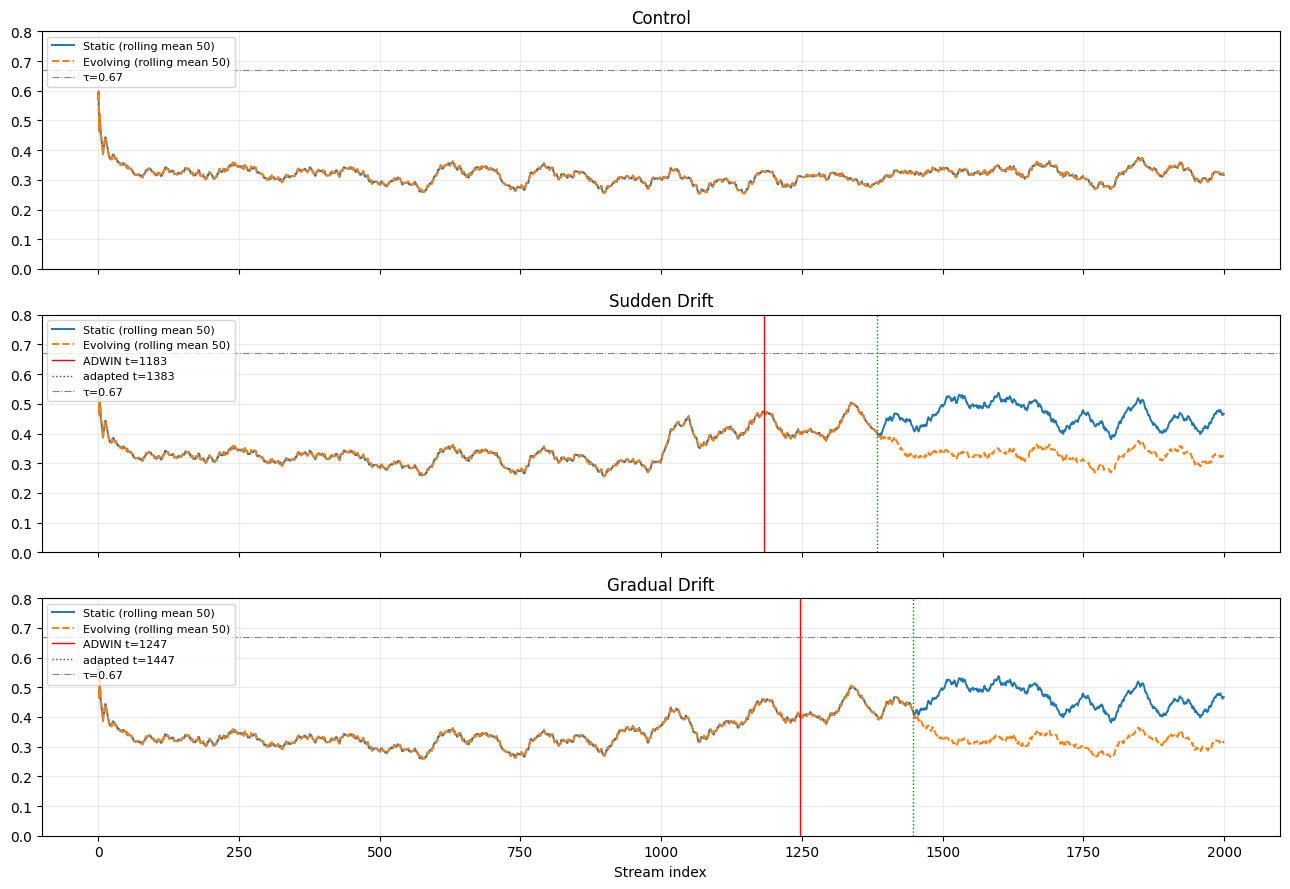

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, scen in zip(axes, scenarios):
    s, e = logs[(scen, "Static")], logs[(scen, "Evolving")]
    roll = lambda x: pd.Series(x).rolling(50, min_periods=1).mean()
    ax.plot(roll(s.score), label="Static (rolling mean 50)", lw=1.4)
    ax.plot(roll(e.score), label="Evolving (rolling mean 50)", lw=1.4, ls="--")
    for ev in events[(scen, "Evolving")]:
        if ev["event"] == "drift_detected":
            ax.axvline(ev["t"], color="red", lw=1, label=f"ADWIN t={ev['t']}")
        if ev["event"] == "adapted":
            ax.axvline(ev["t"], color="green", lw=1, ls=":", label=f"adapted t={ev['t']}")
    ax.axhline(TAU, color="gray", lw=0.8, ls="-.", label="τ=0.67")
    ax.set_title(scen); ax.set_ylim(0, 0.8); ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=.25)
axes[-1].set_xlabel("Stream index")
plt.tight_layout(); plt.savefig(ROOT / "figures" / "09_score_trajectories_all.png", dpi=130); plt.show()

## 9.6 — Lưu kết quả

In [7]:
(ROOT / "results").mkdir(exist_ok=True)
summary.to_csv(ROOT / "results" / "09_experiment_matrix.csv", index=False)
stress_df.to_csv(ROOT / "results" / "09_false_alarm_stress.csv", index=False)
print(summary[["Experiment","Scenario","Model","TP","TN","FP","FN","Precision","Recall","F1","FPR","Balanced Accuracy"]].round(4).to_string(index=False))
print("\nPhase 9: COMPLETE")

Experiment      Scenario    Model  TP   TN  FP  FN  Precision  Recall     F1    FPR  Balanced Accuracy
        E1       Control   Static  13 1927  34  26     0.2766  0.3333 0.3023 0.0173             0.6580
        E2       Control Evolving  13 1927  34  26     0.2766  0.3333 0.3023 0.0173             0.6580
        E3  Sudden Drift   Static  18 1847 114  21     0.1364  0.4615 0.2105 0.0581             0.7017
        E4  Sudden Drift Evolving  15 1905  56  24     0.2113  0.3846 0.2727 0.0286             0.6780
       E5a Gradual Drift   Static  18 1848 113  21     0.1374  0.4615 0.2118 0.0576             0.7020
       E5b Gradual Drift Evolving  14 1900  61  25     0.1867  0.3590 0.2456 0.0311             0.6639

Phase 9: COMPLETE
